# **Predicting Insurance Claim Amounts**

**Objective:** Estimate the medical insurance claim amount (`charges`) based on personal data.

**Dataset:** Medical Cost Personal Dataset  

**Skills Covered:**  
- Regression modeling  
- Feature correlation and visualization  
- Error evaluation using MAE and RMSE

## **1- Import Libraries**

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## **2- Load Dataset**

In [2]:
# Load dataset
df = pd.read_csv("insurance.csv")  # replace with correct path
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Dataset Features:**

- `age` – Age of the primary beneficiary  
- `sex` – Gender (male/female)  
- `bmi` – Body mass index  
- `children` – Number of children covered by health insurance  
- `smoker` – Smoking status (yes/no)  
- `region` – Residential area  
- `charges` – Medical insurance charges (target variable)

## **3- Data Preprocessing**
- Encode categorical features  
- Check for missing values

In [3]:
# Check missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
# Encode categorical variables
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'no':0, 'yes':1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


## **4- Feature Selection**
- Define features (`X`) and target (`y`)

In [5]:
X = df.drop('charges', axis=1)
y = df['charges']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **5- Train Linear Regression Model**

In [6]:
# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

## **6- Evaluate Model Performance**
Use **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**.

In [7]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


## **7- Visualize Impact of Key Features**
We will explore how `BMI`, `age`, and `smoking status` affect insurance charges.

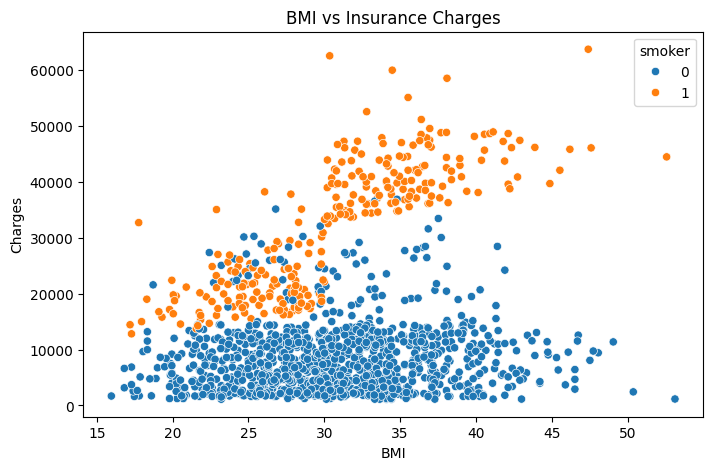

In [8]:
# Scatter plot: BMI vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

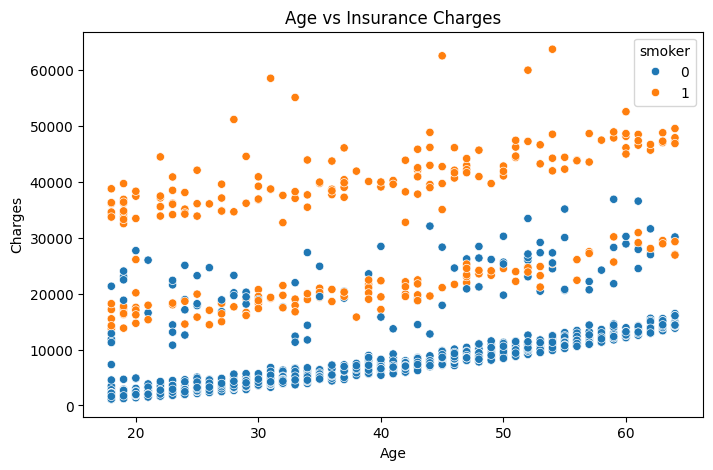

In [9]:
# Scatter plot: Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

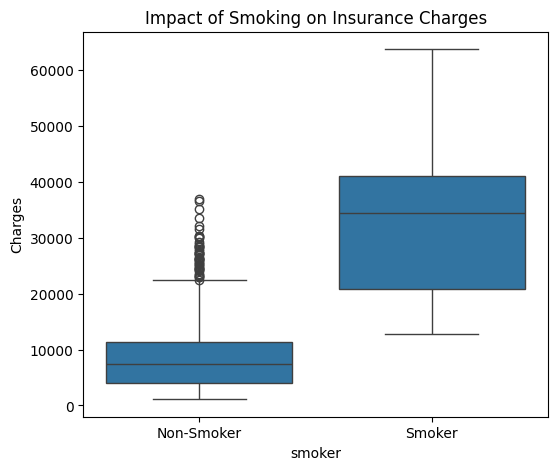

In [10]:
# Boxplot: Smoking Status vs Charges
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Impact of Smoking on Insurance Charges")
plt.xticks([0,1], ['Non-Smoker','Smoker'])
plt.ylabel("Charges")
plt.show()

## **8- Conclusion**

- The **Linear Regression model** successfully predicts insurance charges based on personal and demographic data.  
- **Key insights from visualization:**
  - **Smoking status** has the largest impact on medical insurance charges. Smokers pay significantly higher premiums.  
  - **Age** and **BMI** are positively correlated with charges — older individuals and those with higher BMI tend to have higher costs.  
- **Model Performance:**
  - Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) indicate the average prediction error and show that the model captures general trends well.  